# Cancer microscopy images — 4-model detection, counting & segmentation

**BM3 — Image-based Cancer Cell Detection using Deep Learning** (Rafay Nisar).

Compares four models on the **23 ground-truth annotated images**:

- **YOLOv8** (one-stage, COCO transfer)
- **Faster R-CNN** (two-stage, ResNet-50 FPN)
- **RetinaNet** (one-stage + focal loss — good for dense small cells)
- **Mask R-CNN** (instance **segmentation** — uses your polygon outlines, not just boxes; the previous cancer student listed this as future work)

All share the **same train/val/test split**. Metrics: **mAP@0.5**, **mAP@0.5:0.95**, **count MAE**. Mask R-CNN adds a segmentation visual.

**Data reality:** ~23 images -> test set is only 3-4 -> **proof-of-concept, noisy numbers.** Runtime -> **T4 GPU**. **Untested by me — paste any error and I'll fix it.**

In [ ]:
!pip -q install ultralytics torchmetrics pycocotools
import os, glob, json, random, numpy as np
from google.colab import drive
drive.mount('/content/drive')

SRC = '/content/drive/MyDrive/Cancer Dataset/annotated_images'   # >>> EDIT to where you uploaded it
jsons = sorted(glob.glob(os.path.join(SRC, '*.json')))
print('annotation files found:', len(jsons))
assert len(jsons) > 0, 'No .json found - fix SRC'

Mounted at /content/drive
annotation files found: 23


## 0. Convert labelme -> YOLO boxes + split (keeps polygons in memory for Mask R-CNN)

In [ ]:
import shutil
ROOT = '/content/cancer_yolo'
if os.path.exists(ROOT): shutil.rmtree(ROOT)
for s in ['train', 'valid', 'test']:
    os.makedirs(f'{ROOT}/{s}/images', exist_ok=True); os.makedirs(f'{ROOT}/{s}/labels', exist_ok=True)

def find_image(jp, a):
    base = os.path.splitext(jp)[0]
    for ext in ['.png', '.jpeg', '.jpg', '.PNG', '.JPEG', '.JPG', '.tif', '.tiff']:
        if os.path.exists(base + ext): return base + ext
    cand = os.path.join(SRC, os.path.basename(a.get('imagePath', '')))
    return cand if os.path.exists(cand) else None

def poly_bbox(points, W, H):
    xs = [p[0] for p in points]; ys = [p[1] for p in points]
    x1, y1, x2, y2 = max(0, min(xs)), max(0, min(ys)), min(W, max(xs)), min(H, max(ys))
    return ((x1+x2)/2/W, (y1+y2)/2/H, (x2-x1)/W, (y2-y1)/H) if x2 > x1 and y2 > y1 else None

pairs = []
for jp in jsons:
    a = json.load(open(jp, encoding='utf-8'))
    img = find_image(jp, a)
    if img: pairs.append((img, jp, a))
print('image+label pairs:', len(pairs))

random.seed(42); random.shuffle(pairs)
n = len(pairs); n_test = max(2, int(0.15*n)); n_val = max(2, int(0.15*n))
splits = {'test': pairs[:n_test], 'valid': pairs[n_test:n_test+n_val], 'train': pairs[n_test+n_val:]}

for split, items in splits.items():
    for img, jp, a in items:
        W = a.get('imageWidth'); H = a.get('imageHeight')
        stem = os.path.splitext(os.path.basename(img))[0].replace(' ', '_')
        shutil.copy(img, f'{ROOT}/{split}/images/{stem}{os.path.splitext(img)[1]}')
        lines = []
        for s in a.get('shapes', []):
            bb = poly_bbox(s.get('points', []), W, H)
            if bb: lines.append('0 ' + ' '.join(f'{v:.6f}' for v in bb))
        open(f'{ROOT}/{split}/labels/{stem}.txt', 'w').write('\n'.join(lines))
    print(split, len(items), 'images')

open(f'{ROOT}/data.yaml', 'w').write(f"path: {ROOT}\ntrain: train/images\nval: valid/images\ntest: test/images\nnc: 1\nnames: ['cancer-cell']\n")
print('wrote data.yaml')

image+label pairs: 23
test 3 images
valid 3 images
train 17 images
wrote data.yaml


## 1. YOLOv8

In [ ]:
from ultralytics import YOLO
WORK = '/content/drive/MyDrive/cancer_images'; os.makedirs(WORK, exist_ok=True)
IMG = 1280
YOLO('yolov8s.pt').train(data=f'{ROOT}/data.yaml', epochs=200, imgsz=IMG, batch=4, patience=50,
                         degrees=10, translate=0.1, scale=0.5, fliplr=0.5, mosaic=1.0,
                         project=WORK, name='cancer_yolov8', exist_ok=True)
best = f'{WORK}/cancer_yolov8/weights/best.pt'
ym = YOLO(best).val(data=f'{ROOT}/data.yaml', split='test', imgsz=IMG)
yolo_map50, yolo_map = float(ym.box.map50), float(ym.box.map)
ym_model = YOLO(best)
test_imgs = sorted(glob.glob(f'{ROOT}/test/images/*'))
gts = np.array([sum(1 for l in open(ip.replace('/images/','/labels/').rsplit('.',1)[0]+'.txt') if l.strip()) for ip in test_imgs])
yp = np.array([len(ym_model.predict(ip, conf=0.25, imgsz=IMG, verbose=False)[0].boxes) for ip in test_imgs])
yolo_mae = float(np.abs(yp - gts).mean())
print('YOLOv8: mAP@0.5', round(yolo_map50,3), '| mAP@.5:.95', round(yolo_map,3), '| count MAE', round(yolo_mae,2))

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
Ultralytics 8.4.137 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/cancer_yolo/data.yaml, degrees=10, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=200, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, form

## 2. Shared torchvision helpers (datasets, build, train, eval)

In [ ]:
import torch, torchvision
import torchvision.transforms.functional as TF
from torch.utils.data import Dataset, DataLoader
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor
from torchmetrics.detection import MeanAveragePrecision
from PIL import Image, ImageDraw
dev = 'cuda' if torch.cuda.is_available() else 'cpu'

# box dataset (Faster R-CNN, RetinaNet) - reads YOLO labels written above
class BoxDS(Dataset):
    def __init__(self, split):
        self.imgs = sorted(glob.glob(f'{ROOT}/{split}/images/*'))
    def __len__(self): return len(self.imgs)
    def __getitem__(self, i):
        ip = self.imgs[i]; img = Image.open(ip).convert('RGB'); W, H = img.size
        lp = ip.replace('/images/', '/labels/').rsplit('.', 1)[0] + '.txt'
        boxes, labels = [], []
        if os.path.exists(lp):
            for line in open(lp):
                p = line.split()
                if len(p) < 5: continue
                cx, cy, bw, bh = map(float, p[1:5])
                x1=(cx-bw/2)*W; y1=(cy-bh/2)*H; x2=(cx+bw/2)*W; y2=(cy+bh/2)*H
                if x2>x1 and y2>y1: boxes.append([x1,y1,x2,y2]); labels.append(1)
        return TF.to_tensor(img), {'boxes': torch.as_tensor(boxes, dtype=torch.float32).reshape(-1,4),
                                   'labels': torch.as_tensor(labels, dtype=torch.int64)}

# mask dataset (Mask R-CNN) - rasterises the original polygons
class MaskDS(Dataset):
    def __init__(self, items): self.items = items
    def __len__(self): return len(self.items)
    def __getitem__(self, i):
        img_path, jp, a = self.items[i]
        img = Image.open(img_path).convert('RGB'); W, H = img.size
        boxes, labels, masks = [], [], []
        for s in a.get('shapes', []):
            pts = s.get('points', [])
            if len(pts) < 3: continue
            m = Image.new('L', (W, H), 0); ImageDraw.Draw(m).polygon([tuple(p) for p in pts], outline=1, fill=1)
            m = np.array(m, dtype=np.uint8); ys, xs = np.where(m)
            if len(xs) == 0: continue
            boxes.append([xs.min(), ys.min(), xs.max(), ys.max()]); labels.append(1); masks.append(m)
        if not boxes:
            masks_t = torch.zeros((0, H, W), dtype=torch.uint8)
        else:
            masks_t = torch.as_tensor(np.stack(masks), dtype=torch.uint8)
        return TF.to_tensor(img), {'boxes': torch.as_tensor(boxes, dtype=torch.float32).reshape(-1,4),
                                   'labels': torch.as_tensor(labels, dtype=torch.int64), 'masks': masks_t}

def collate(b): return tuple(zip(*b))

def build_fasterrcnn():
    m = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights='DEFAULT')
    m.roi_heads.box_predictor = FastRCNNPredictor(m.roi_heads.box_predictor.cls_score.in_features, 2)
    return m
def build_retinanet():
    return torchvision.models.detection.retinanet_resnet50_fpn(weights=None, num_classes=2, weights_backbone='DEFAULT')
def build_maskrcnn():
    m = torchvision.models.detection.maskrcnn_resnet50_fpn(weights='DEFAULT')
    m.roi_heads.box_predictor = FastRCNNPredictor(m.roi_heads.box_predictor.cls_score.in_features, 2)
    m.roi_heads.mask_predictor = MaskRCNNPredictor(m.roi_heads.mask_predictor.conv5_mask.in_channels, 256, 2)
    return m

def train_det(model, loader, epochs=30, lr=0.005):
    model.to(dev); opt = torch.optim.SGD([p for p in model.parameters() if p.requires_grad], lr=lr, momentum=0.9, weight_decay=5e-4)
    for ep in range(epochs):
        model.train(); tot = 0
        for imgs, tgs in loader:
            imgs = [im.to(dev) for im in imgs]; tgs = [{k: v.to(dev) for k, v in t.items()} for t in tgs]
            loss = sum(model(imgs, tgs).values()); opt.zero_grad(); loss.backward(); opt.step(); tot += loss.item()
        if (ep+1) % 10 == 0: print(f'  epoch {ep+1}/{epochs} loss {tot/len(loader):.3f}')
    return model

def eval_det(model, loader, score_thr=0.5):
    model.eval(); metric = MeanAveragePrecision(box_format='xyxy'); pc, gc = [], []
    with torch.no_grad():
        for imgs, tgs in loader:
            outs = model([im.to(dev) for im in imgs])
            preds, targets = [], []
            for o, t in zip(outs, tgs):
                keep = o['scores'] > score_thr
                preds.append({'boxes': o['boxes'][keep].cpu(), 'scores': o['scores'][keep].cpu(), 'labels': o['labels'][keep].cpu()})
                targets.append({'boxes': t['boxes'], 'labels': t['labels']})
                pc.append(int(keep.sum())); gc.append(int(len(t['labels'])))
            metric.update(preds, targets)
    mp = metric.compute(); pc, gc = np.array(pc), np.array(gc)
    return float(mp['map_50']), float(mp['map']), float(np.abs(pc-gc).mean())

## 3. Faster R-CNN, RetinaNet, Mask R-CNN

In [ ]:
box_train = DataLoader(BoxDS('train'), batch_size=2, shuffle=True, collate_fn=collate)
box_test  = DataLoader(BoxDS('test'),  batch_size=1, shuffle=False, collate_fn=collate)
det = {}
for name, builder in [('FasterRCNN-ResNet50', build_fasterrcnn), ('RetinaNet-ResNet50', build_retinanet)]:
    print(name)
    m = train_det(builder(), box_train, epochs=30)
    det[name] = eval_det(m, box_test)
    print('  ->', tuple(round(v,3) for v in det[name]))
    del m; torch.cuda.empty_cache()

FasterRCNN-ResNet50
Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:01<00:00, 151MB/s]


  epoch 10/30 loss 0.168
  epoch 20/30 loss 0.076
  epoch 30/30 loss 0.068
  -> (0.752, 0.555, 1.0)
RetinaNet-ResNet50
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 152MB/s]


  epoch 10/30 loss 1.423
  epoch 20/30 loss 1.540
  epoch 30/30 loss 1.338
  -> (0.0, 0.0, 2.667)


In [ ]:
# Mask R-CNN (segmentation) - trains on polygons, batch 1 (large masks)
mask_train = DataLoader(MaskDS(splits['train']), batch_size=1, shuffle=True, collate_fn=collate)
mask_test  = DataLoader(MaskDS(splits['test']),  batch_size=1, shuffle=False, collate_fn=collate)
print('Mask R-CNN')
maskm = train_det(build_maskrcnn(), mask_train, epochs=20)
det['MaskRCNN-ResNet50'] = eval_det(maskm, mask_test)
print('  ->', tuple(round(v,3) for v in det['MaskRCNN-ResNet50']))

Mask R-CNN
Downloading: "https://download.pytorch.org/models/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth" to /root/.cache/torch/hub/checkpoints/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth


100%|██████████| 170M/170M [00:01<00:00, 159MB/s]


  epoch 10/20 loss 0.321
  epoch 20/20 loss 0.192
  -> (0.624, 0.414, 1.0)


In [ ]:
from torchvision.models.detection.retinanet import RetinaNetClassificationHead
from functools import partial

def build_retinanet2():
    m = torchvision.models.detection.retinanet_resnet50_fpn(weights='DEFAULT')  # COCO-pretrained
    na = m.head.classification_head.num_anchors
    try:
        m.head.classification_head = RetinaNetClassificationHead(256, na, 2, norm_layer=partial(torch.nn.GroupNorm, 32))
    except TypeError:
        m.head.classification_head = RetinaNetClassificationHead(256, na, 2)
    return m

print('RetinaNet (pretrained + head-swap, lr 1e-3, 45 epochs)')
m = train_det(build_retinanet2(), box_train, epochs=45, lr=1e-3)
det['RetinaNet-ResNet50'] = eval_det(m, box_test)
print('->', tuple(round(v, 3) for v in det['RetinaNet-ResNet50']))
del m; torch.cuda.empty_cache()

import pandas as pd
rows = [{'model':'YOLOv8','mAP50':round(yolo_map50,3),'mAP50_95':round(yolo_map,3),'count_MAE':round(yolo_mae,2)}]
for name,(m50,mm,mae) in det.items():
    rows.append({'model':name,'mAP50':round(m50,3),'mAP50_95':round(mm,3),'count_MAE':round(mae,2)})
df = pd.DataFrame(rows); print(df.to_string(index=False))
df.to_csv('/content/drive/MyDrive/cancer_images_compare.csv', index=False)

RetinaNet (pretrained + head-swap, lr 1e-3, 45 epochs)
Downloading: "https://download.pytorch.org/models/retinanet_resnet50_fpn_coco-eeacb38b.pth" to /root/.cache/torch/hub/checkpoints/retinanet_resnet50_fpn_coco-eeacb38b.pth


100%|██████████| 130M/130M [00:00<00:00, 175MB/s]


  epoch 10/45 loss 0.188
  epoch 20/45 loss 0.062
  epoch 30/45 loss 0.043
  epoch 40/45 loss 0.029
-> (0.752, 0.471, 0.667)
              model  mAP50  mAP50_95  count_MAE
             YOLOv8  0.669     0.379       2.67
FasterRCNN-ResNet50  0.752     0.555       1.00
 RetinaNet-ResNet50  0.752     0.471       0.67
  MaskRCNN-ResNet50  0.624     0.414       1.00


## 4. Segmentation visual (Mask R-CNN's extra capability)

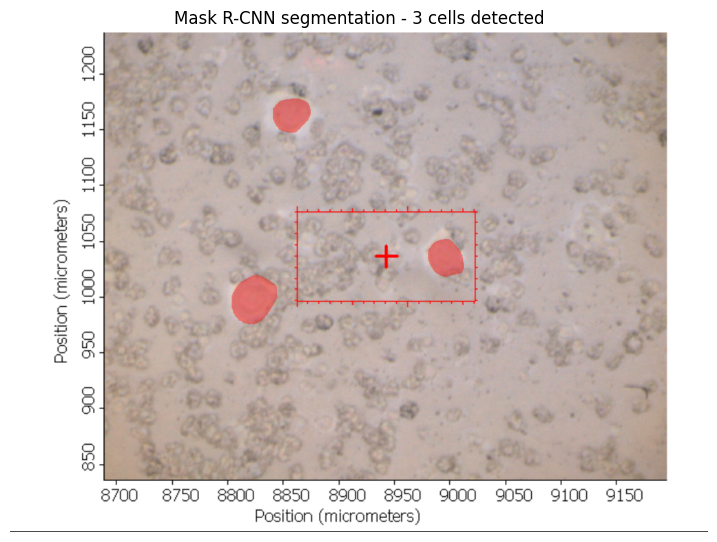

In [ ]:
import matplotlib.pyplot as plt
maskm.eval()
img_t, tgt = MaskDS(splits['test'])[0]
with torch.no_grad():
    out = maskm([img_t.to(dev)])[0]
keep = out['scores'] > 0.5
base = (img_t.permute(1,2,0).numpy()*255).astype('uint8').copy()
overlay = base.copy()
for mk in out['masks'][keep].cpu().numpy():
    overlay[mk[0] > 0.5] = [255, 0, 0]
plt.figure(figsize=(9,7)); plt.imshow((0.6*base + 0.4*overlay).astype('uint8')); plt.axis('off')
plt.title(f'Mask R-CNN segmentation - {int(keep.sum())} cells detected'); plt.show()

## 5. Comparison (all four models)

In [ ]:
import pandas as pd
rows = [{'model': 'YOLOv8', 'mAP50': round(yolo_map50,3), 'mAP50_95': round(yolo_map,3), 'count_MAE': round(yolo_mae,2)}]
for name, (m50, m, mae) in det.items():
    rows.append({'model': name, 'mAP50': round(m50,3), 'mAP50_95': round(m,3), 'count_MAE': round(mae,2)})
df = pd.DataFrame(rows)
print(df.to_string(index=False))
df.to_csv('/content/drive/MyDrive/cancer_images_compare.csv', index=False)
print('\nsaved -> cancer_images_compare.csv')

              model  mAP50  mAP50_95  count_MAE
             YOLOv8  0.669     0.379       2.67
FasterRCNN-ResNet50  0.752     0.555       1.00
 RetinaNet-ResNet50  0.752     0.471       0.67
  MaskRCNN-ResNet50  0.624     0.414       1.00

saved -> cancer_images_compare.csv


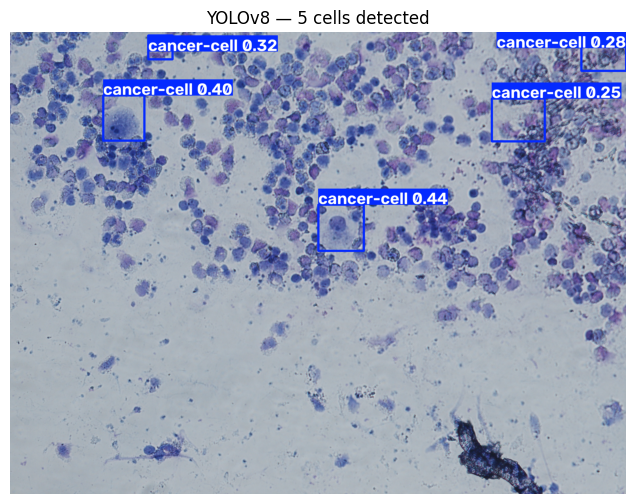

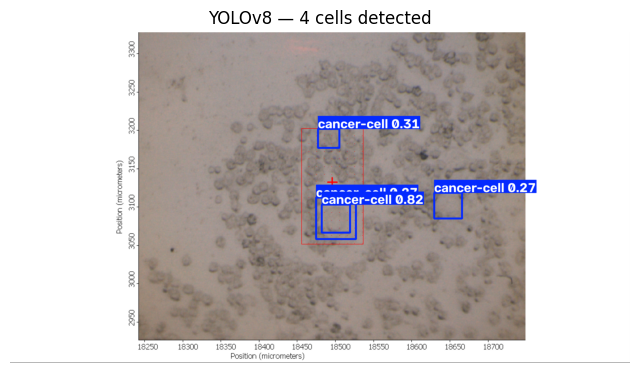

In [ ]:
import matplotlib.pyplot as plt, glob
for ip in sorted(glob.glob(f'{ROOT}/test/images/*'))[:2]:
    r = ym_model.predict(ip, conf=0.25, imgsz=IMG, verbose=False)[0]
    plt.figure(figsize=(8,6)); plt.imshow(r.plot()[:, :, ::-1]); plt.axis('off')
    plt.title(f'YOLOv8 — {len(r.boxes)} cells detected'); plt.show()

In [ ]:
import glob
print("cancer_images subfolders:")
print(glob.glob('/content/drive/MyDrive/cancer_images/*'))
print("\nany results.png on Drive:")
print(glob.glob('/content/drive/MyDrive/**/results.png', recursive=True)[:10])
print("\nany runs folder in /content:")
print(glob.glob('/content/**/cancer_yolov8*', recursive=True)[:10])

cancer_images subfolders:
['/content/drive/MyDrive/cancer_images/cancer_yolov8', '/content/drive/MyDrive/cancer_images/cancer_base', '/content/drive/MyDrive/cancer_images/cancer_cbam']

any results.png on Drive:
['/content/drive/MyDrive/clover_yolo/clover_v8s/results.png', '/content/drive/MyDrive/clover_yolo/clover_v8s_hi/results.png', '/content/drive/MyDrive/clover_yolo/clover_v8s_cbam/results.png', '/content/drive/MyDrive/cancer_images/cancer_yolov8/results.png', '/content/drive/MyDrive/cancer_images/cancer_base/results.png', '/content/drive/MyDrive/cancer_images/cancer_cbam/results.png']

any runs folder in /content:
['/content/drive/MyDrive/cancer_images/cancer_yolov8']


results.png


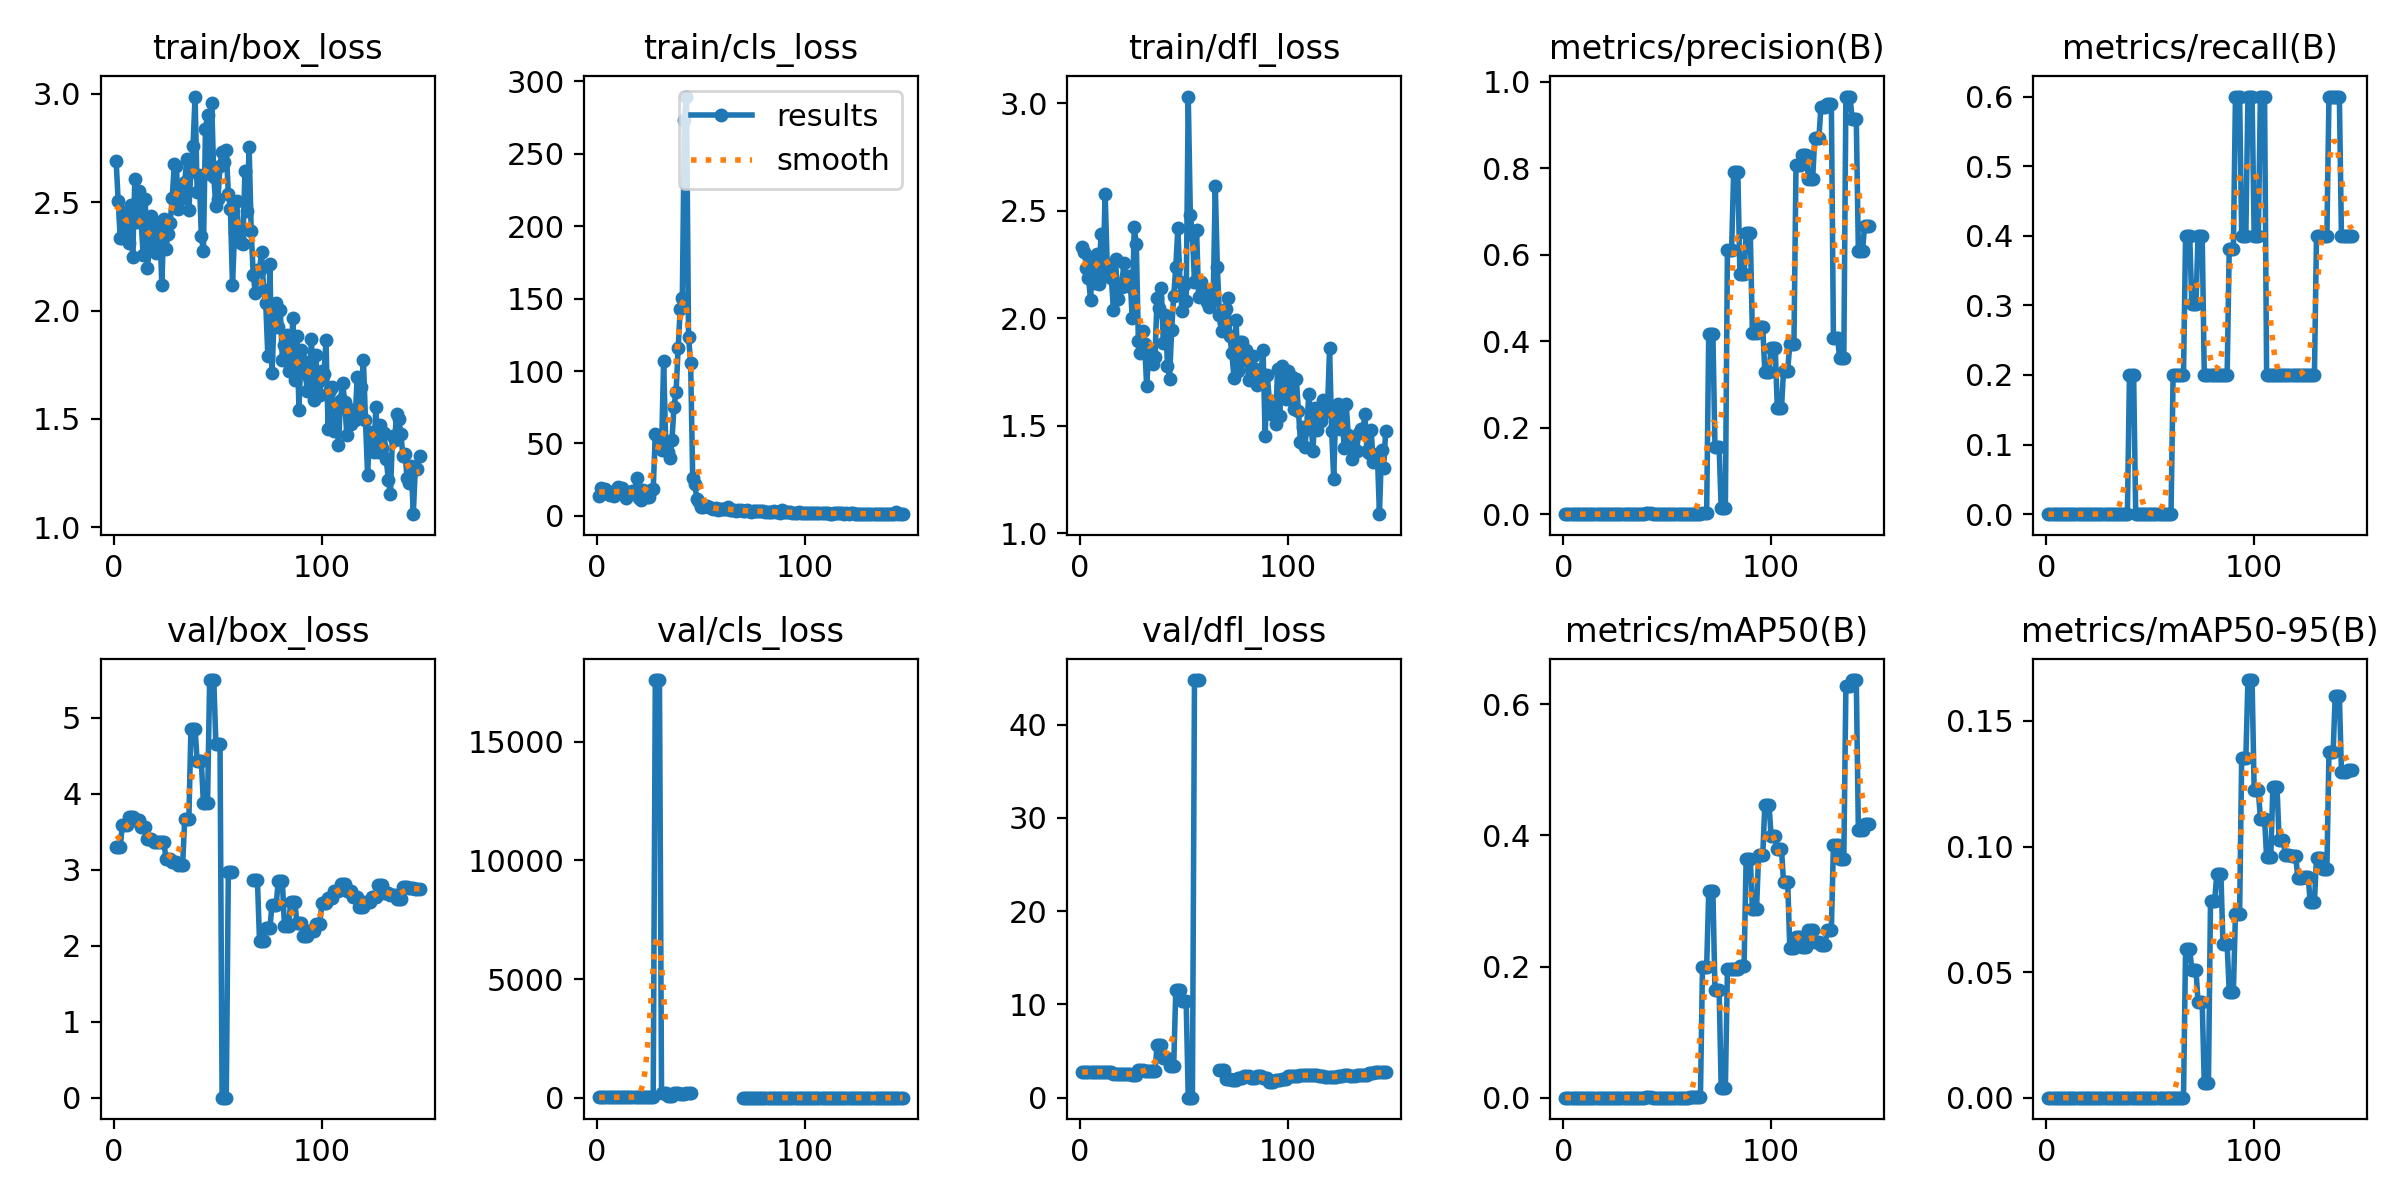

confusion_matrix.png


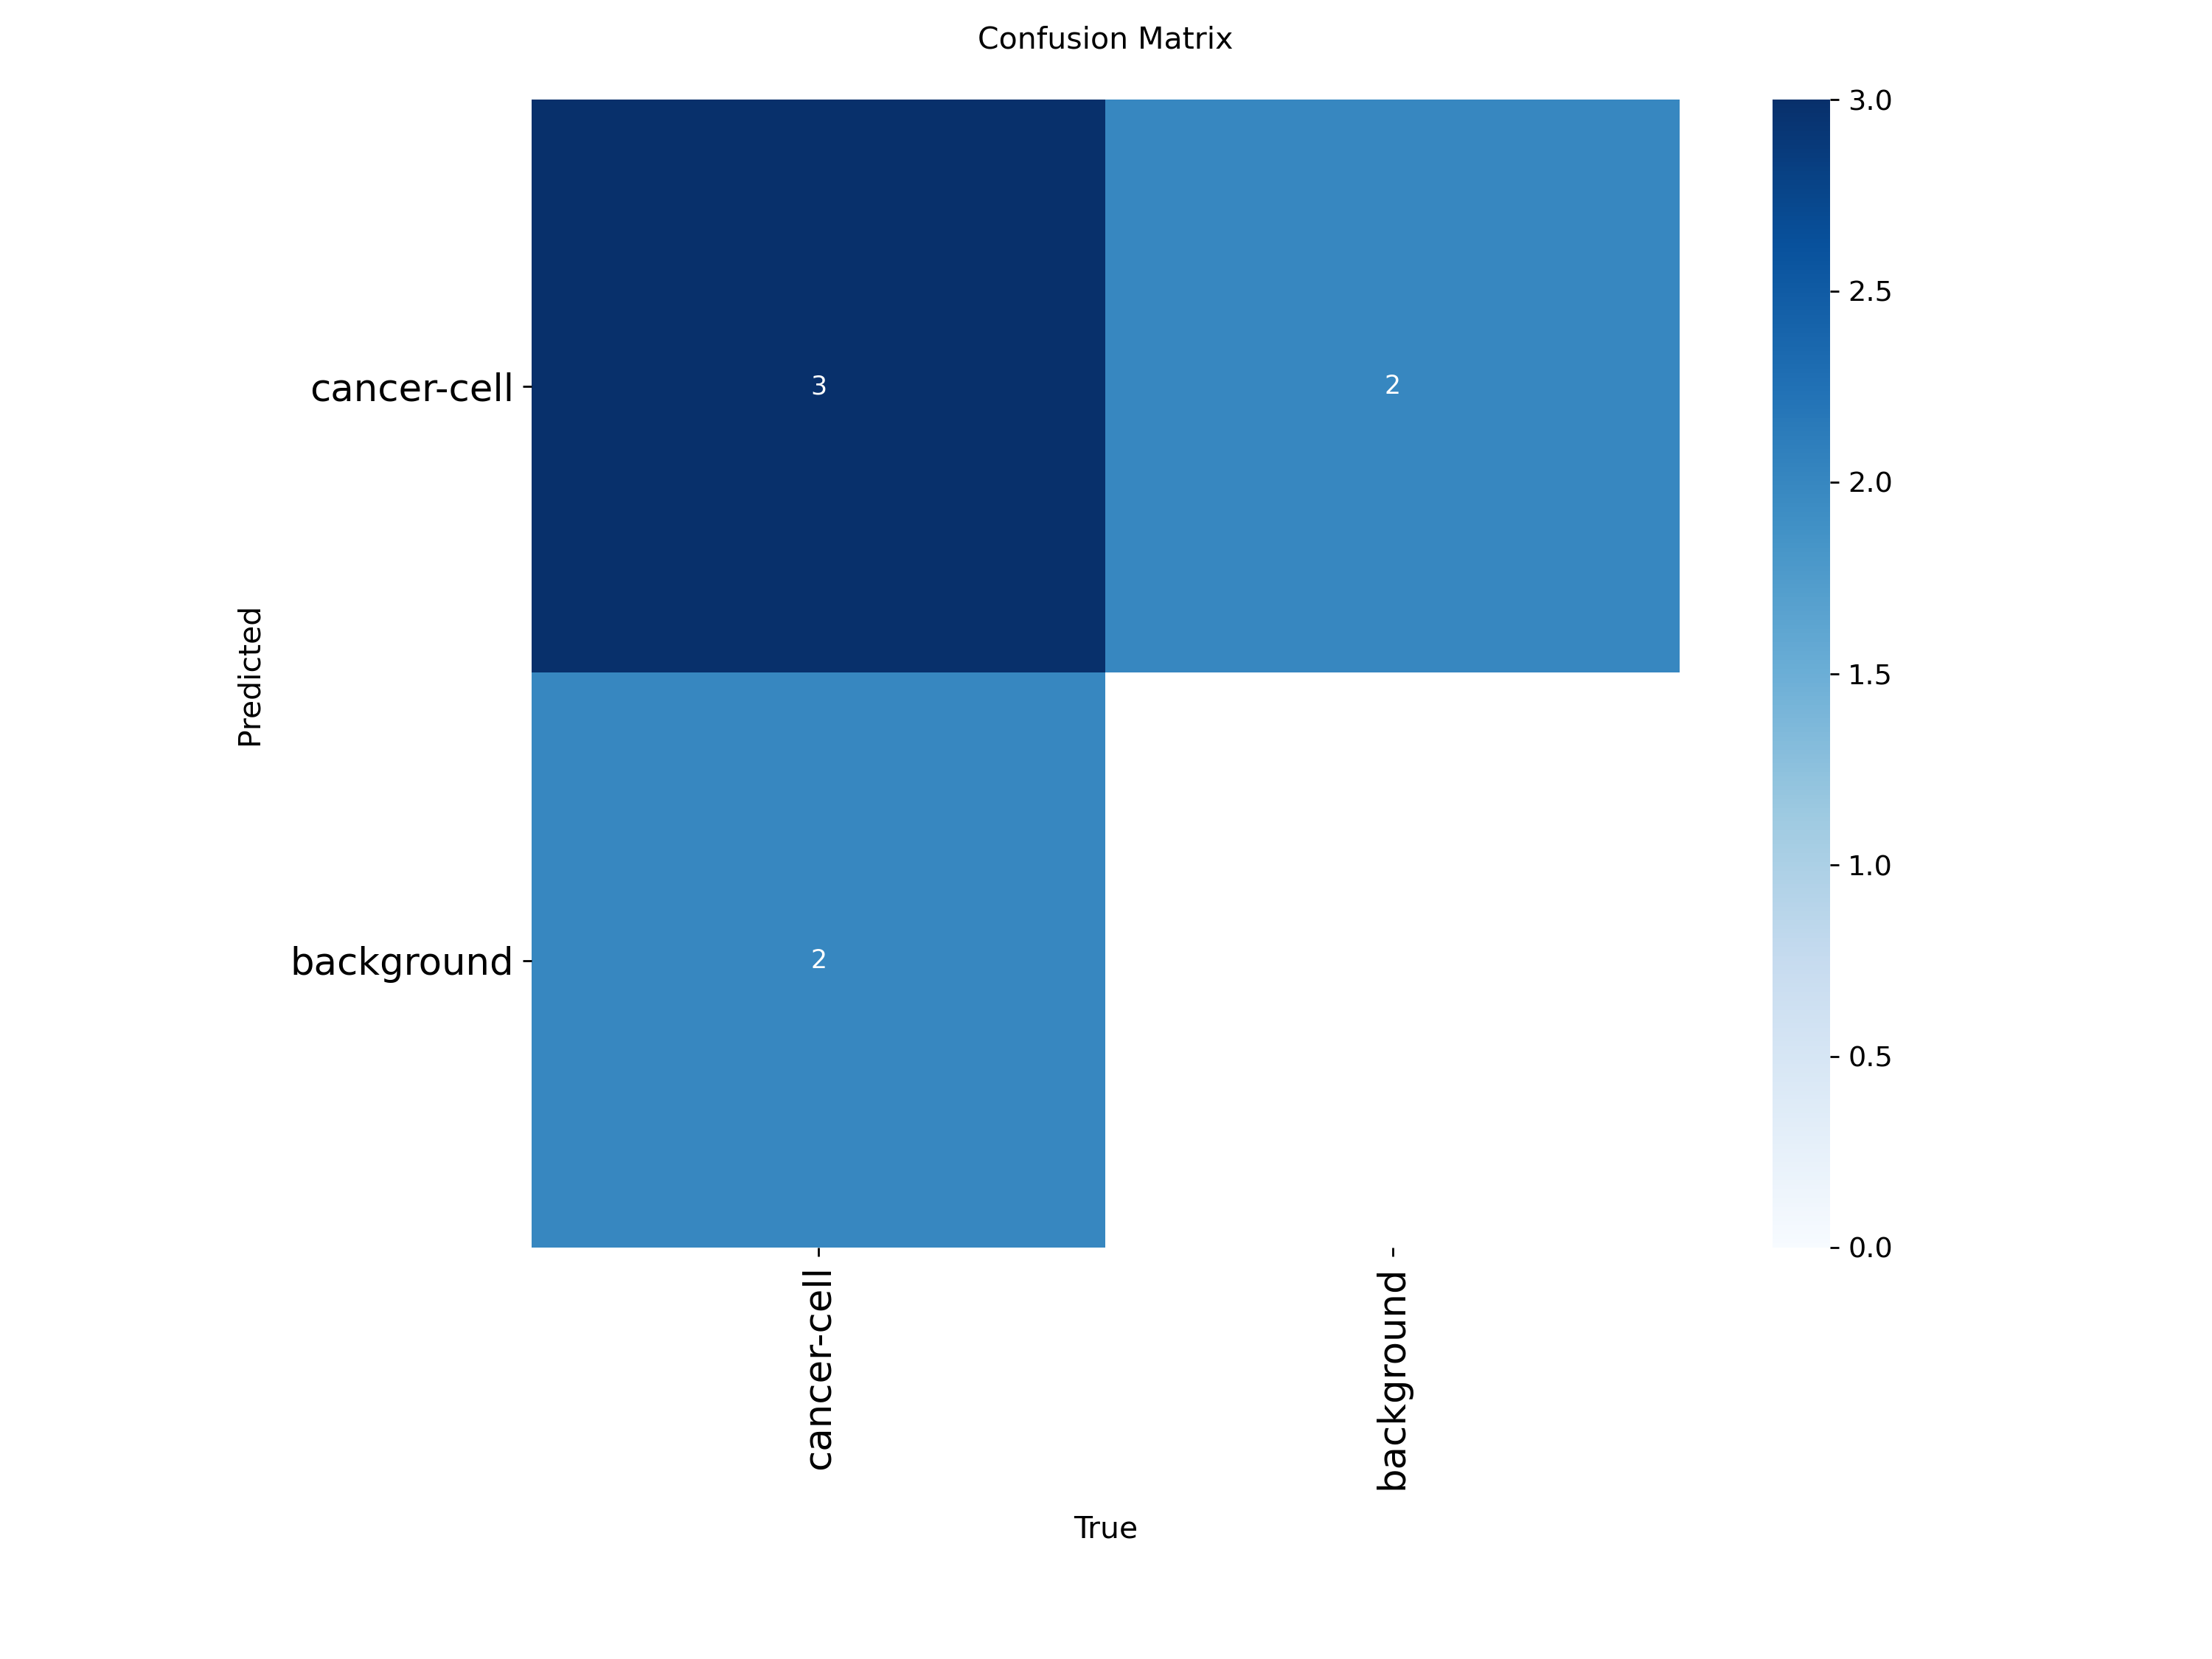

not found: /content/drive/MyDrive/cancer_images/cancer_yolov8/PR_curve.png


In [ ]:
from IPython.display import Image as IPyImage, display
import os
run = '/content/drive/MyDrive/cancer_images/cancer_yolov8'   # YOLO run folder on Drive
for f in ['results.png', 'confusion_matrix.png', 'PR_curve.png']:
    p = os.path.join(run, f)
    if os.path.exists(p):
        print(f); display(IPyImage(p))
    else:
        print('not found:', p)

## 6. Notes

- Four models, same split: **YOLOv8, Faster R-CNN, RetinaNet, Mask R-CNN**. The previous cancer student used YOLOv8 only, so this comparison + segmentation is new.
- Test set is 3-4 images -> report as proof-of-concept.
- Mask R-CNN gives **cell outlines** (segmentation), doing what that student listed as future work.
- If OOM on Mask R-CNN, it's the large masks - keep batch=1, or downscale images.
- Next: **CBAM attention** on YOLOv8 for these cancer images (baseline vs +attention).